# Notebook for practical exercises | Week #4 Lesson #2

## Introduction

This notebook contains practical hands-on exercises for the lesson about *Convolutional Neural Networks for Segmentation*.

After this session, you will know how to evaluate and improve the performance of a classifier for a real-world segmentation problem:
- Train CNNs for pixel‑wise (semantic) segmentation
- Benchmark several model architectures (UNet, FCN, DeepLabV3).
- Compare segmentation results using Dice and IoU scores.

## Dataset

We will use the [The Brain Resection Multimodal Imaging Database](https://www.cancerimagingarchive.net/collection/remind/) [1]. The Brain Resection Multimodal Imaging Database (ReMIND) contains pre- and intra-operative brain MRI collected on 114 consecutive patients who were surgically treated with image-guided tumor resection between 2018 and 2022.

[1] Juvekar, P., Dorent, R., Kögl, F., Torio, E., Barr, C., Rigolo, L., Galvin, C., Jowkar, N., Kazi, A., Haouchine, N., Cheema, H., Navab, N., Pieper, S., Wells, W. M., Bi, W. L., Golby, A., Frisken, S., & Kapur, T. (2023). The Brain Resection Multimodal Imaging Database (ReMIND) (Version 1) [dataset]. The Cancer Imaging Archive. [https://doi.org/10.7937/3RAG-D070](https://doi.org/10.7937/3RAG-D070)

Retrieve the repository

In [ ]:
!git clone https://github.com/albarqounilab/AIM.git

Import libraries

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

import sys
import warnings
warnings.filterwarnings(action="ignore")
os.environ["PYTHONWARNINGS"] = "ignore"

import argparse
import math
import os
from glob import glob

!pip install -U segmentation-models-pytorch -q
import albumentations as A
import numpy as np
import pandas as pd
import SimpleITK as sitk
sitk.ProcessObject.SetGlobalWarningDisplay(False)
import torch
import torch.nn as nn
import torch.optim as optim
from albumentations.pytorch import ToTensorV2
from sklearn.model_selection import train_test_split
from torch.utils.data import Dataset, DataLoader
from tqdm import tqdm

sitk.ProcessObject_SetGlobalWarningDisplay(False)

### Download

If needed, run the following cells to download and unzip the dataset. If you already have the dataset downloaded, comment the two lines.

<div class="alert alert-block alert-danger">
<b>Replace the <code>DATA_PATH</code> with the path where you want to store the data folder. By default, it will be stored at the root of this repository.</b> <br>
<b>If you have already downloaded the dataset, comment the following cell by adding a <code>#</code> before the <code>!</code></b>
</div>

In [ ]:
DATA_PATH = './'

# !curl https://uni-bonn.sciebo.de/s/s1t8QUZ02MF1Qoh/download --output {DATA_PATH}/data.zip
# !unzip {DATA_PATH}/data.zip -d {DATA_PATH}

### Dataset Class

Similarly to what we have done for classification and detection, we need to create a `Dataset` class for the segmentation task.
Observe the following cell and compare with the classes we created in lesson #1.

<div class="alert alert-block alert-info">
<b>Q1.</b> Load the metadata csv file of the ReMIND dataset and observe the data.
</div>

In [ ]:
# Load and observe available data
clinical_df = pd.read_csv(f'{DATA_PATH}/data/ReMIND/ReMIND_metadata.csv')
clinical_df.head() # Print the 5 fist rows of the dataframe

,Case Number,Age,Sex,Race,Ethnicity,Laterality,Previous Craniotomy,WHO Grade,Histopathology
0,1,41,Male,White,Not Hispanic,Right,No,3,Astrocytoma
1,2,22,Female,White,Not Hispanic,Right,No,2,Astrocytoma
2,3,30,Male,Asian,Not Hispanic,Left,No,2,Oligodendroglioma
3,4,23,Male,White,Hispanic,Left,No,1,Dysembryoplastic neuroepithelial tumor
4,5,27,Male,White,Not Hispanic,Right,No,Not assigned,Non-tumor epileptogenic brain parenchyma and g...


In [ ]:
class SegmentationDataset(Dataset):

    def __init__(self, clinical_df: pd.DataFrame, data_dir: str, size: int = 512, augment: bool = True):
        self.data_dir = data_dir
        self.size = size
        self.slices: list[tuple[np.ndarray, np.ndarray]] = []  # (img_slice, mask_slice)

        if augment:
            self.image_t = A.Compose(
                [
                    A.Resize(size, size, interpolation=0),
                    A.HorizontalFlip(),
                    A.Normalize(mean=0.0, std=1.0),
                    ToTensorV2(),
                ]
            )
            self.mask_t = A.Compose(
                [
                    A.Resize(size, size, interpolation=0),
                    ToTensorV2(transpose_mask=True),
                ]
            )
        else:
            self.image_t = A.Compose([A.Resize(size, size, interpolation=0), A.Normalize(0.0, 1.0), ToTensorV2()])
            self.mask_t = A.Compose([A.Resize(size, size, interpolation=0), ToTensorV2(transpose_mask=True)])

        # Build slice index list once. We ignore patients without tumor mask
        for patient, _ in tqdm(
            zip(clinical_df["Case Number"], clinical_df["WHO Grade"]),
            total=len(clinical_df),
            desc="Indexing slices",
        ):
            idx = str(patient).zfill(3)
            img_dir = glob(f"{data_dir}/data/ReMIND/sub-{idx}/anat/T1w*")  # There might be *_T1w, *_T1ce, etc.
            seg_path = glob(f"{data_dir}/data/ReMIND/sub-{idx}/seg/ReMIND-{idx}-preop-SEG-tumor-*.nrrd")
            if not img_dir or not seg_path:
                continue

            # Load volumes once – keep in RAM temporarily.
            img_sitk = load_dicom_series_to_3d_image(img_dir[0])
            img_np = sitk.GetArrayFromImage(img_sitk)  # (Z, H, W)

            mask_sitk = sitk.ReadImage(seg_path[0])
            mask_sitk = reconstruct_mask_in_image_space(mask_sitk, img_sitk)
            mask_np = sitk.GetArrayFromImage(mask_sitk).astype(np.uint8)

            assert img_np.shape == mask_np.shape, "Image/mask dim mismatch"

            # For each axial slice, append if any tumor present.
            for k in range(img_np.shape[0]):
                if mask_np[k].any():
                    self.slices.append((img_np[k], mask_np[k]))

    def __len__(self):
        return len(self.slices)

    def __getitem__(self, idx: int):
        img_slice, mask_slice = self.slices[idx]
        transformed = self.image_t(image=img_slice, mask=mask_slice)
        img_t = transformed["image"].float()            # [1, H, W]
        mask_t = transformed["mask"].float()            # [H, W]
        mask_t = mask_t.unsqueeze(0)                    # now [1, H, W]
        return img_t, mask_t

# Helper functions to read the dicom and reconstruct the mask in image space
def load_dicom_series_to_3d_image(series_path: str) -> sitk.Image:
    """Read a DICOM series (folder full of slices) into a 3‑D SimpleITK image."""
    reader = sitk.ImageSeriesReader()
    dicom_names = reader.GetGDCMSeriesFileNames(series_path)
    reader.SetFileNames(dicom_names)
    img = reader.Execute()
    return img


def reconstruct_mask_in_image_space(mask_sitk: sitk.Image, reference_image: sitk.Image) -> sitk.Image:
    """Resample *mask_sitk* into the physical space & grid of *reference_image*."""
    return sitk.Resample(
        mask_sitk,
        reference_image,
        sitk.Transform(),
        sitk.sitkNearestNeighbor,
        0,
        mask_sitk.GetPixelID(),
    )


<div class="alert alert-block alert-info">
<b>Q2.</b> In the previous cell, we created the <code>Dataset</code> class for the segmentation task. Observe the code. <br>
    Create an instance of <code>SegmentationDataset</code> containing all ReMIND samples and print a few samples.
</div>

In [ ]:
seg_dataset = SegmentationDataset(clinical_df, DATA_PATH)

Indexing slices: 100%|████████████████████████████████████████████████████████████████| 114/114 [00:34<00:00,  3.34it/s]


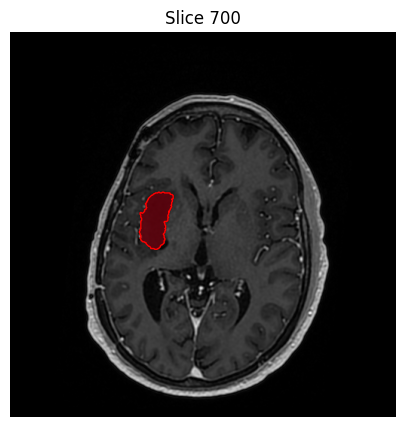

In [ ]:
# pick your slice
slice_idx = 700

# load and reshape
img  = np.transpose(seg_dataset[slice_idx][0], (1,2,0))
mask = np.transpose(seg_dataset[slice_idx][1], (1,2,0)).squeeze()  # H×W

# mask-out all values != 1
mask1 = np.ma.masked_where(mask != 1, mask)

# plot
fig, ax = plt.subplots(figsize=(10,5))
ax.imshow(img, cmap='gray')
# force the colormap to span [0,1] so value==1 is pure red
ax.imshow(mask1,cmap='Reds',alpha=0.8,vmin=0,vmax=1)      # map 1 → top of colormap (red)
ax.contour(mask, levels=[0.5], colors='red', linewidths=1)
ax.axis('off')
ax.set_title(f'Slice {slice_idx}')
plt.show()

## Tumor Segmentation

We will use CNN models for binary semantic segmentation: predicting a tumor mask for each input MRI slice.
We will:
- Load a pretrained segmentation model (e.g., FCN).
- Train on the dataset using Dice or BCE loss.
- Visualize predictions and compare to ground truth.
- Benchmark multiple models (UNet, FCN, DeepLabV3).

### Dataset split

Before, we need to split our dataset with training, validation and test sets.

<div class="alert alert-block alert-info">
<b>Q1.</b> Split the dataset using the <code>train_test_split</code> function from scikit-learn and create the three variables: <code>train_dataset</code>, <code>val_dataset</code>, <code>test_dataset</code>.
</div>

In [ ]:
patient_list = clinical_df['Case Number'].unique()

patient_train, patient_test = train_test_split(
    patient_list, # List or array to split
    test_size= 0.2, # Size of the subset
    random_state=42)

patient_train, patient_val = train_test_split(
    patient_train, # List or array to split
    test_size= 0.1, # Size of the subset
    random_state=42)

train_df = clinical_df.loc[clinical_df['Case Number'].isin(patient_train)]
test_df = clinical_df.loc[clinical_df['Case Number'].isin(patient_test)]
val_df = clinical_df.loc[clinical_df['Case Number'].isin(patient_val)]

Load the DICOM datasets once

In [ ]:
train_dataset = SegmentationDataset(train_df, DATA_PATH)
val_dataset = SegmentationDataset(val_df, DATA_PATH)

Indexing slices: 100%|██████████████████████████████████████████████████████████████████| 10/10 [00:03<00:00,  3.24it/s]


Lets visulize some examples from our dataloader

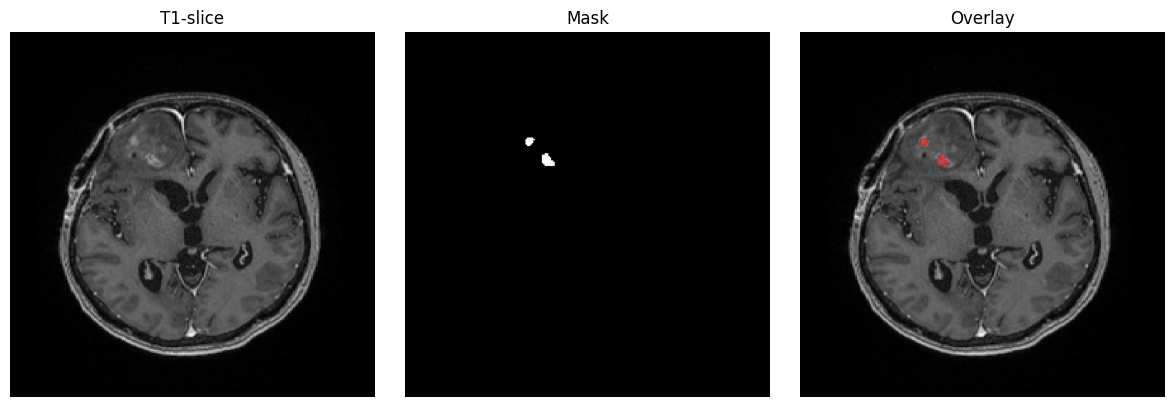

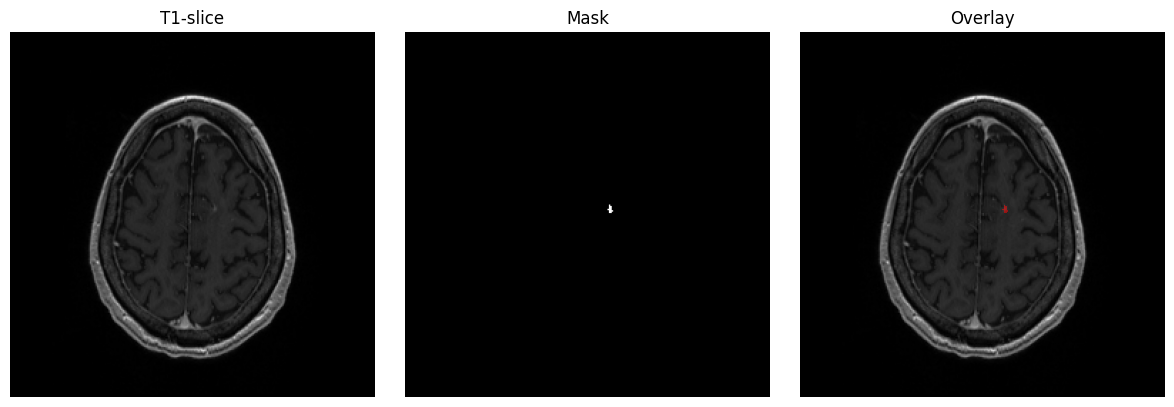

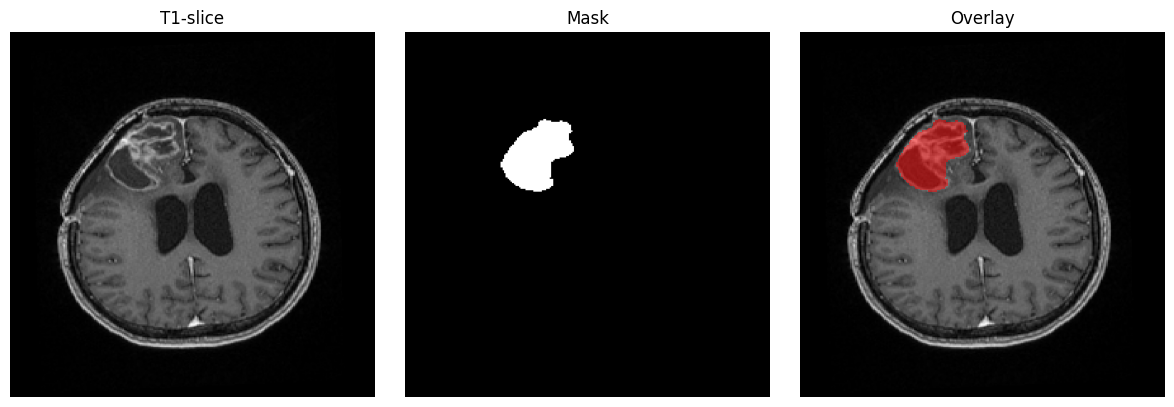

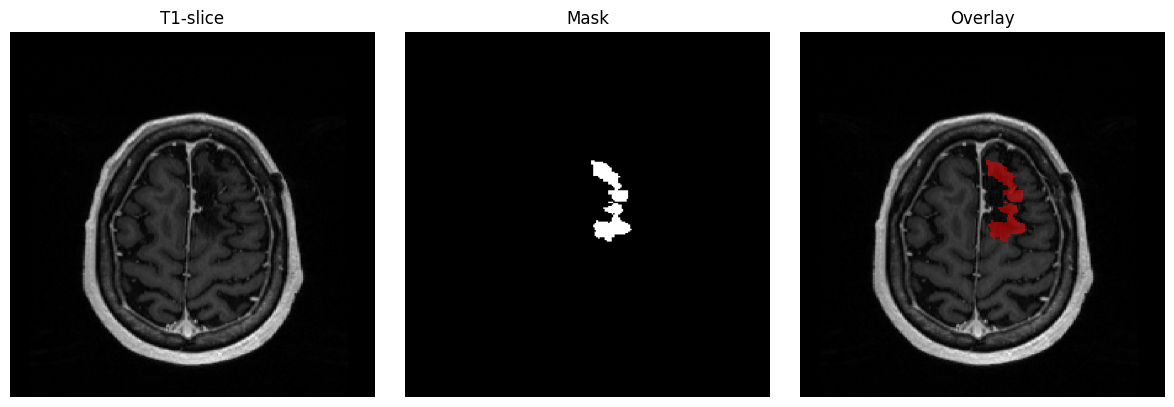

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from torch.utils.data import DataLoader
ds = train_dataset
# `ds` is your SegmentationDataset
loader = DataLoader(ds, batch_size=4, shuffle=True, num_workers=2, pin_memory=True)
imgs, masks = next(iter(loader))   # imgs: [4,1,H,W], masks: [4,1,H,W]

# Colormap: index 0 → transparent, 1 → red
cmap = ListedColormap(['none', 'red'])

for i in range(imgs.size(0)):
    img = imgs[i,0].cpu().numpy()
    msk = masks[i,0].cpu().numpy().astype(int)  # ensure 0/1 integers

    fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(12, 4))
    ax1.imshow(img, cmap='gray')
    ax1.set_title('T1‑slice'); ax1.axis('off')

    ax2.imshow(msk, cmap='gray')
    ax2.set_title('Mask'); ax2.axis('off')

    ax3.imshow(img, cmap='gray')
    ax3.imshow(msk, cmap=cmap, alpha=0.5, interpolation='none')
    ax3.set_title('Overlay')
    ax3.axis('off')

    plt.tight_layout()
    plt.show()


In the following, we will create and fine-tune a segmentation network named FCN. Always inspect the in_channels of the layer you’re replacing, and patch both main and auxiliary classifiers so they match your desired number of output classes.

In [ ]:
import segmentation_models_pytorch as smp
from torch.optim.lr_scheduler import CosineAnnealingLR

model = smp.Unet(encoder_name="resnet50", encoder_weights="imagenet", in_channels=1, classes=1) # Binary class
model.to(device)
print(model)

Unet(
  (encoder): ResNetEncoder(
    (conv1): Conv2d(1, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): Bottleneck(
        (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (downsample): Sequential(
      

<div class="alert alert-block alert-info">
<b>Q2.</b> In the following cell, we implemented the training loop for segmentation. Implement the corresponding validation loop.
</div>

In [ ]:
def train_epoch(model, loader, criterion, optimizer, scaler, device):
    model.train()
    epoch_loss = 0.0
    pbar = tqdm(loader, desc="Train", leave=False)
    for imgs, masks in pbar:
        imgs, masks = imgs.to(device), masks.to(device)
        optimizer.zero_grad(set_to_none=True)
        with torch.cuda.amp.autocast(enabled=scaler is not None):
            preds = model(imgs)
            loss = criterion(preds, masks)
        if scaler is not None:
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
        else:
            loss.backward()
            optimizer.step()
        epoch_loss += loss.item() * imgs.size(0)
    return epoch_loss / len(loader.dataset)


def validate(model, loader, criterion, device):
    model.eval()
    val_loss = 0.0
    dices = []
    with torch.no_grad():
        for imgs, masks in tqdm(loader, desc="Val", leave=False):
            imgs, masks = imgs.to(device), masks.to(device)
            preds = model(imgs)
            loss = criterion(preds, masks)
            val_loss += loss.item() * imgs.size(0)
            dices.append(dice_coeff(preds.cpu(), masks.cpu()))
    return val_loss / len(loader.dataset), np.mean(dices)


def dice_coeff(pred: torch.Tensor, target: torch.Tensor, eps: float = 1e-6):
    pred = torch.sigmoid(pred) > 0.5
    intersection = (pred & (target > 0.5)).float().sum(dim=(1, 2, 3))
    union = pred.float().sum(dim=(1, 2, 3)) + target.float().sum(dim=(1, 2, 3))
    dice = (2.0 * intersection + eps) / (union + eps)
    return dice.mean().item()


In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
checkpoint_dir= "./checkpoint/"
os.makedirs(checkpoint_dir, exist_ok=True)

batch_size=16
val_split= 0.3
lr = 3e-4
mixed_precision = "store_true"
epochs= 10

train_loader = DataLoader(train_ds,batch_size=batch_size,shuffle=True,num_workers=8,pin_memory=torch.cuda.is_available())
val_loader = DataLoader(val_ds,batch_size=batch_size,shuffle=False,num_workers=2,pin_memory=torch.cuda.is_available(),)

criterion = nn.BCEWithLogitsLoss()
optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-5)
scheduler = CosineAnnealingLR(optimizer, T_max=epochs, eta_min=1e-6)

scaler = torch.cuda.amp.GradScaler() if mixed_precision and torch.cuda.is_available() else None

best_dice = 0.0
for epoch in range(1, epochs + 1):
  print(f"\nEpoch {epoch}/{epochs} – LR: {optimizer.param_groups[0]['lr']:.1e}")
  train_loss = train_epoch(model, train_loader, criterion, optimizer, scaler, device)
  val_loss, val_dice = validate(model, val_loader, criterion, device)
  print(f"  Train loss: {train_loss:.4f}")
  print(f"  Val   loss: {val_loss:.4f}  |  Dice: {val_dice:.4f}")
  scheduler.step()

# Save best model
if val_dice > best_dice:
    best_dice = val_dice
    ckpt_path = os.path.join(checkpoint_dir, f"fcn_segmentation{epoch:03d}_dice{best_dice:.4f}.pt")
    torch.save({"model_state_dict": model.state_dict(), "dice": best_dice}, ckpt_path)
    print(f" Saved new best checkpoint to {ckpt_path}")


Epoch 1/10 – LR: 3.0e-04


  Train loss: 0.0120
  Val   loss: 0.0132  |  Dice: 0.6092

Epoch 2/10 – LR: 2.9e-04


  Train loss: 0.0111
  Val   loss: 0.0131  |  Dice: 0.5782

Epoch 3/10 – LR: 2.7e-04


  Train loss: 0.0110
  Val   loss: 0.0137  |  Dice: 0.5787

Epoch 4/10 – LR: 2.4e-04


  Train loss: 0.0099
  Val   loss: 0.0125  |  Dice: 0.6107

Epoch 5/10 – LR: 2.0e-04


...

  Train loss: 0.0085
  Val   loss: 0.0104  |  Dice: 0.6154

Epoch 7/10 – LR: 1.0e-04


  Train loss: 0.0077
  Val   loss: 0.0101  |  Dice: 0.6529

Epoch 8/10 – LR: 6.3e-05


  Train loss: 0.0074
  Val   loss: 0.0095  |  Dice: 0.6467

Epoch 9/10 – LR: 3.0e-05


  Train loss: 0.0070
  Val   loss: 0.0082  |  Dice: 0.6841

Epoch 10/10 – LR: 8.3e-06


  Train loss: 0.0068
  Val   loss: 0.0091  |  Dice: 0.6615
 Saved new best checkpoint to ./checkpoint/fcn_segmentation010_dice0.6615.pt


Here the model is training with a pure BCEWithLogitsLoss, but we are also monitoring Dice. BCE will push every pixel toward zero, therefore we need to include the dice criterion into our objective function

In [ ]:
class BCEDiceLoss(nn.Module):
    def __init__(self):
        super().__init__()
        self.bce = nn.BCEWithLogitsLoss()

    def forward(self, pred, target):
        bce = self.bce(pred, target)
        pred = torch.sigmoid(pred)
        dice = (2.0 * (pred * target).sum() + 1.0) / (pred.sum() + target.sum() + 1.0)
        return 0.5 * bce + 0.5 * (1.0 - dice)

class DiceLoss(nn.Module):
    def __init__(self, eps=1e-7):
        super().__init__()
        self.eps = eps

    def forward(self, pred, targets):
        """
        pred: raw output from the model (N, 1, H, W)
        targets: ground truth masks (N, 1, H, W) or (N, H, W)
        """
        probs = torch.sigmoid(pred)
        targets = targets.float()

        probs = probs.view(probs.size(0), -1)
        targets = targets.view(targets.size(0), -1)

        intersection = (probs * targets).sum(dim=1)
        union = probs.sum(dim=1) + targets.sum(dim=1)

        dice = (2. * intersection + self.eps) / (union + self.eps)
        loss = 1 - dice
        return loss.mean()


In [ ]:
model = smp.Unet(encoder_name="resnet50", encoder_weights="imagenet", in_channels=1, classes=1) # Binary class
model.to(device)

batch_size=16
val_split= 0.3
lr = 3e-4
mixed_precision = "store_true"
epochs= 10

train_loader = DataLoader(train_ds,batch_size=batch_size,shuffle=True,num_workers=8,pin_memory=torch.cuda.is_available())
val_loader = DataLoader(val_ds,batch_size=batch_size,shuffle=False,num_workers=2,pin_memory=torch.cuda.is_available(),)

criterion = DiceLoss()
optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-5)
scheduler = CosineAnnealingLR(optimizer, T_max=epochs, eta_min=1e-6)

scaler = torch.cuda.amp.GradScaler() if mixed_precision and torch.cuda.is_available() else None

best_dice = 0.0
for epoch in range(1, epochs + 1):
  print(f"\nEpoch {epoch}/{epochs} – LR: {optimizer.param_groups[0]['lr']:.1e}")
  train_loss = train_epoch(model, train_loader, criterion, optimizer, scaler, device)
  val_loss, val_dice = validate(model, val_loader, criterion, device)
  print(f"  Train loss: {train_loss:.4f}")
  print(f"  Val   loss: {val_loss:.4f}  |  Dice: {val_dice:.4f}")
  scheduler.step()

# Save best model
if val_dice > best_dice:
    best_dice = val_dice
    ckpt_path = os.path.join(checkpoint_dir, f"fcn_segmentation{epoch:03d}_dice{best_dice:.4f}.pt")
    torch.save({"model_state_dict": model.state_dict(), "dice": best_dice}, ckpt_path)
    print(f" Saved new best checkpoint to {ckpt_path}")

<div class="alert alert-block alert-info">
<b>Q3.</b> In the previous training, we used a <code>BCELoss</code> to optimize performance. But segmentation models can also be trained using other metrics, such as the DICE coefficient. In the following, we implemented the <code>DiceLoss</code> and <code>BCEDiceLoss</code>.
    Train the FCN model using these two losses, print the results on the validation set and compare.
</div>

In [ ]:
model = smp.Unet(encoder_name="resnet50", encoder_weights="imagenet", in_channels=1, classes=1) # Binary class
model.to(device)

batch_size=16
val_split= 0.3
lr = 3e-4
mixed_precision = "store_true"
epochs= 20

train_loader = DataLoader(train_ds,batch_size=batch_size,shuffle=True,num_workers=8,pin_memory=torch.cuda.is_available())
val_loader = DataLoader(val_ds,batch_size=batch_size,shuffle=False,num_workers=2,pin_memory=torch.cuda.is_available(),)

criterion = BCEDiceLoss()
optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-5)
scheduler = CosineAnnealingLR(optimizer, T_max=epochs, eta_min=1e-6)

scaler = torch.cuda.amp.GradScaler() if mixed_precision and torch.cuda.is_available() else None

best_dice = 0.0
for epoch in range(1, epochs + 1):
  print(f"\nEpoch {epoch}/{epochs} – LR: {optimizer.param_groups[0]['lr']:.1e}")
  train_loss = train_epoch(model, train_loader, criterion, optimizer, scaler, device)
  val_loss, val_dice = validate(model, val_loader, criterion, device)
  print(f"  Train loss: {train_loss:.4f}")
  print(f"  Val   loss: {val_loss:.4f}  |  Dice: {val_dice:.4f}")
  scheduler.step()

# Save best model
if val_dice > best_dice:
    best_dice = val_dice
    ckpt_path = os.path.join(checkpoint_dir, f"fcn_segmentation{epoch:03d}_dice{best_dice:.4f}.pt")
    torch.save({"model_state_dict": model.state_dict(), "dice": best_dice}, ckpt_path)
    print(f" Saved new best checkpoint to {ckpt_path}")


Epoch 1/20 – LR: 3.0e-04


  Train loss: 0.5673
  Val   loss: 0.4559  |  Dice: 0.3643

Epoch 2/20 – LR: 3.0e-04


  Train loss: 0.3519
  Val   loss: 0.2807  |  Dice: 0.4114

Epoch 3/20 – LR: 2.9e-04


  Train loss: 0.2298
  Val   loss: 0.2217  |  Dice: 0.4570

Epoch 4/20 – LR: 2.8e-04


  Train loss: 0.1883
  Val   loss: 0.1757  |  Dice: 0.4967

Epoch 5/20 – LR: 2.7e-04


...

  Train loss: 0.0982
  Val   loss: 0.1081  |  Dice: 0.6081

Epoch 17/20 – LR: 3.0e-05


  Train loss: 0.0948
  Val   loss: 0.1118  |  Dice: 0.5959

Epoch 18/20 – LR: 1.7e-05


  Train loss: 0.0922
  Val   loss: 0.1114  |  Dice: 0.6021

Epoch 19/20 – LR: 8.3e-06


  Train loss: 0.0906
  Val   loss: 0.1061  |  Dice: 0.6137

Epoch 20/20 – LR: 2.8e-06


  Train loss: 0.0900
  Val   loss: 0.1081  |  Dice: 0.6058
 Saved new best checkpoint to ./checkpoint/fcn_segmentation020_dice0.6058.pt


In [ ]:
model = smp.Unet(encoder_name="resnet50", encoder_weights="imagenet", in_channels=1, classes=1) # Binary class
model.to(device)

batch_size=16
val_split= 0.3
lr = 3e-4
mixed_precision = "store_true"
epochs= 20

train_loader = DataLoader(train_ds,batch_size=batch_size,shuffle=True,num_workers=8,pin_memory=torch.cuda.is_available())
val_loader = DataLoader(val_ds,batch_size=batch_size,shuffle=False,num_workers=2,pin_memory=torch.cuda.is_available(),)

criterion = DiceLoss()
optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-5)
scheduler = CosineAnnealingLR(optimizer, T_max=epochs, eta_min=1e-6)

scaler = torch.cuda.amp.GradScaler() if mixed_precision and torch.cuda.is_available() else None

best_dice = 0.0
for epoch in range(1, epochs + 1):
  print(f"\nEpoch {epoch}/{epochs} – LR: {optimizer.param_groups[0]['lr']:.1e}")
  train_loss = train_epoch(model, train_loader, criterion, optimizer, scaler, device)
  val_loss, val_dice = validate(model, val_loader, criterion, device)
  print(f"  Train loss: {train_loss:.4f}")
  print(f"  Val   loss: {val_loss:.4f}  |  Dice: {val_dice:.4f}")
  scheduler.step()

# Save best model
if val_dice > best_dice:
    best_dice = val_dice
    ckpt_path = os.path.join(checkpoint_dir, f"fcn_segmentation{epoch:03d}_dice{best_dice:.4f}.pt")
    torch.save({"model_state_dict": model.state_dict(), "dice": best_dice}, ckpt_path)
    print(f" Saved new best checkpoint to {ckpt_path}")


Epoch 1/20 – LR: 3.0e-04


  Train loss: 0.8842
  Val   loss: 0.7255  |  Dice: 0.3037

Epoch 2/20 – LR: 3.0e-04


  Train loss: 0.6702
  Val   loss: 0.5998  |  Dice: 0.4231

Epoch 3/20 – LR: 2.9e-04


  Train loss: 0.5726
  Val   loss: 0.5954  |  Dice: 0.4162

Epoch 4/20 – LR: 2.8e-04


  Train loss: 0.5224
  Val   loss: 0.5080  |  Dice: 0.4964

Epoch 5/20 – LR: 2.7e-04


...

  Train loss: 0.3634
  Val   loss: 0.3777  |  Dice: 0.6231

Epoch 17/20 – LR: 3.0e-05


  Train loss: 0.3584
  Val   loss: 0.3757  |  Dice: 0.6250

Epoch 18/20 – LR: 1.7e-05


  Train loss: 0.3570
  Val   loss: 0.3670  |  Dice: 0.6336

Epoch 19/20 – LR: 8.3e-06


  Train loss: 0.3549
  Val   loss: 0.3657  |  Dice: 0.6349

Epoch 20/20 – LR: 2.8e-06


  Train loss: 0.3487
  Val   loss: 0.3741  |  Dice: 0.6266
 Saved new best checkpoint to ./checkpoint/fcn_segmentation020_dice0.6266.pt


## Evaluation

Now, we will evaluate using:
* Dice Score
* Mean IoU
* Pixel-wise Precision/Recall

<div class="alert alert-block alert-info">
<b>Q4.</b> Complete the following functions to compute the DICE score and IoU. Complete the validation loop to incorporate these metrics.
</div>

In [ ]:
def compute_iou(pred_mask, true_mask, threshold=0.5, eps=1e-7):
    """
    Computes IoU between predicted and ground truth masks.
    pred_mask, true_mask: torch tensors of shape (N, 1, H, W)
    """
    pred = (torch.sigmoid(pred_mask) > threshold).float()
    true = (true_mask > 0.5).float()

    intersection = (pred * true).sum(dim=(1, 2, 3))
    union = pred.sum(dim=(1, 2, 3)) + true.sum(dim=(1, 2, 3)) - intersection

    iou = (intersection + eps) / (union + eps)
    return iou.mean().item()

def compute_precision_recall(pred_mask, true_mask, threshold=0.5, eps=1e-7):
    """
    Computes pixel-level precision and recall.
    """
    pred = (torch.sigmoid(pred_mask) > threshold).float()
    true = (true_mask > 0.5).float()

    TP = (pred * true).sum(dim=(1, 2, 3))
    FP = (pred * (1 - true)).sum(dim=(1, 2, 3))
    FN = ((1 - pred) * true).sum(dim=(1, 2, 3))

    precision = (TP + eps) / (TP + FP + eps)
    recall = (TP + eps) / (TP + FN + eps)

    return precision.mean().item(), recall.mean().item()

def eval_loop(model, dataloader, criterion, device):
    model.eval()
    val_loss = 0.0
    dice_scores = []

    with torch.no_grad():
        for images, masks in dataloader:
            images = images.to(device)
            masks = masks.to(device)

            outputs = model(images, )["out"]
            loss = criterion(outputs, masks)
            val_loss += loss.item()

            dice = dice_score(outputs, masks)
            dice_scores.append(dice)

    return val_loss / len(dataloader), sum(dice_scores) / len(dice_scores)

<div class="alert alert-block alert-info">
<b>Q5.</b> Run the evaluation loop with all metrics on the three models and visualize the results.
</div>

In [ ]:

model = smp.Unet(encoder_name="resnet50", encoder_weights="imagenet", in_channels=1, classes=1) # Binary class
model.to(device)

checkpoint_path = "./checkpoint/best_model_epoch020_dice0.6219.pt" # Replace with the actual path to your saved checkpoint

checkpoint = torch.load(checkpoint_path, map_location=device, weights_only=False)
model.load_state_dict(checkpoint["model_state_dict"])

model.eval()
test_dataset = SegmentationDataset(test_df, DATA_PATH)
test_dataloader = DataLoader(test_dataset, batch_size=1, num_workers=8, pin_memory=True)

_, test_dice = validate(model, test_dataloader, criterion, device)
print('DICE score:', val_dice)

Indexing slices: 100%|██████████████████████████████████████████████████████████████████| 23/23 [00:07<00:00,  2.99it/s]
                                                                                                                        

Validation loss: 0.3740570898591537
DICE score: 0.6265773937890404


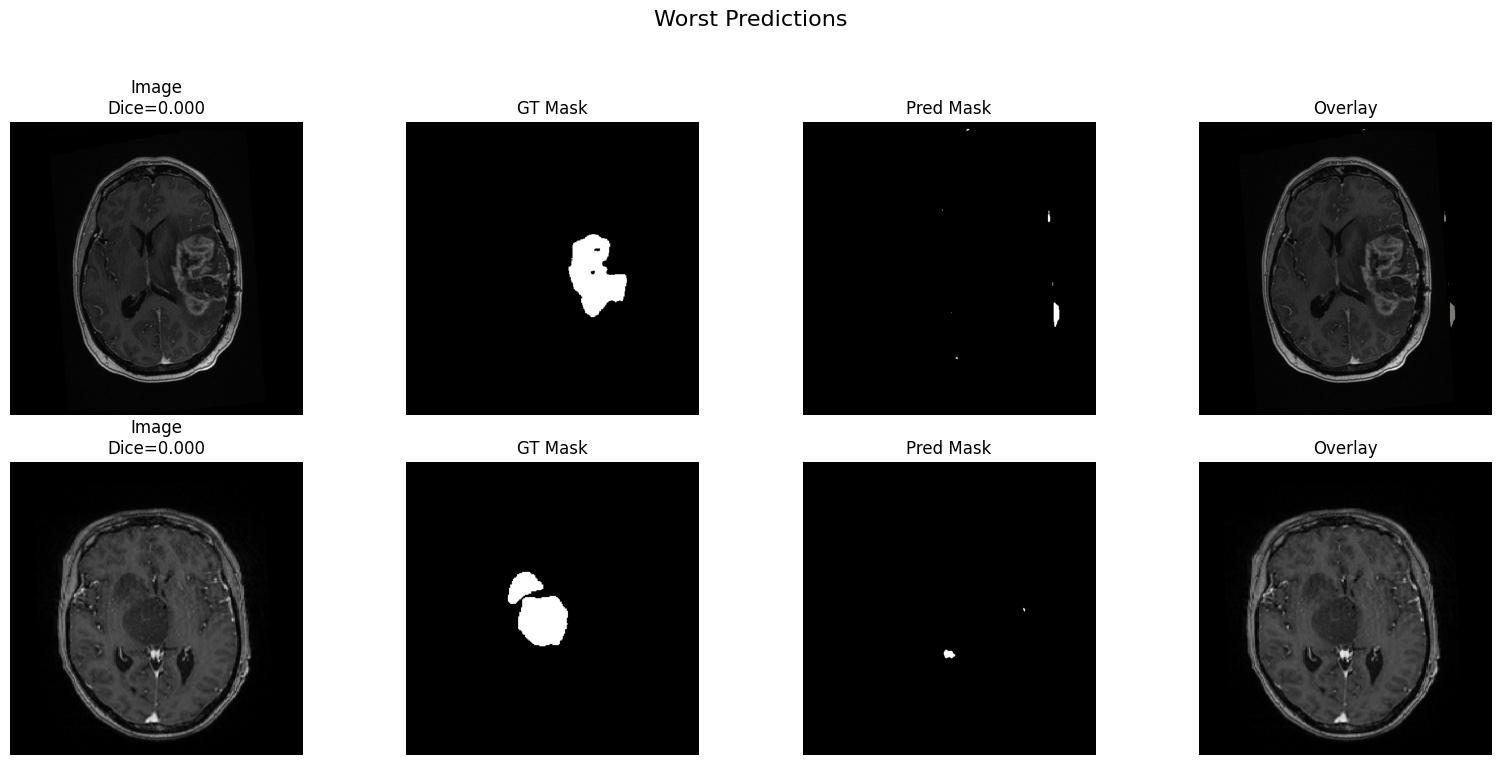

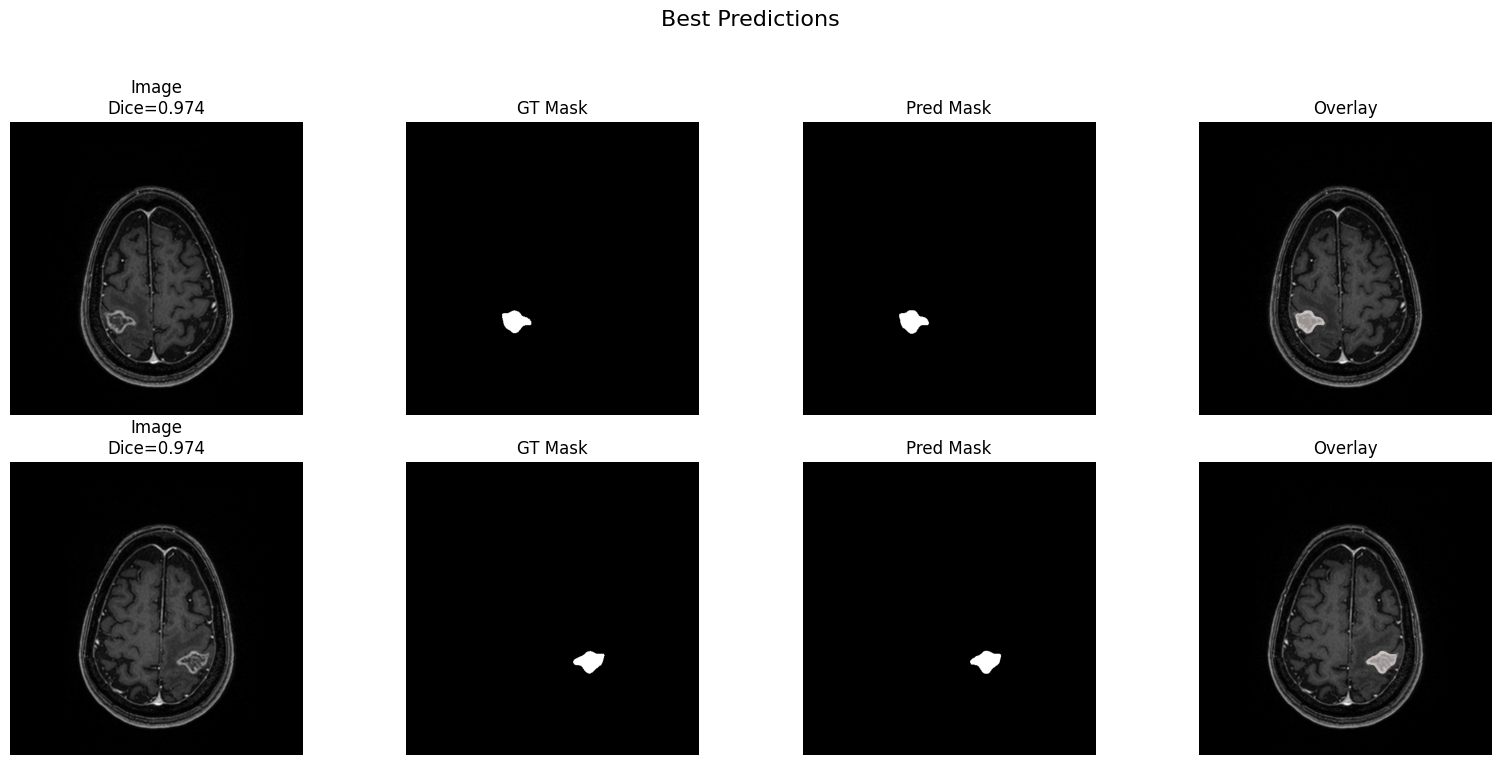

In [ ]:
model.eval()
results = []
with torch.no_grad():
    for imgs, masks in test_dataloader:
        imgs = imgs.to(device)           # [1,1,H,W]
        masks = masks.to(device)         # [1,1,H,W]
        preds = torch.sigmoid(model(imgs))  # [1,1,H,W], in [0,1]

        # Binarize at 0.5
        pred_bin = (preds > 0.5).float()

        # Compute Dice for this slice
        inter = (pred_bin * masks).sum()
        union = pred_bin.sum() + masks.sum()
        dice = ((2 * inter) + 1e-6) / (union + 1e-6)
        dice_val = dice.item()

        # Move to CPU numpy
        img_np  = imgs[0,0].cpu().numpy()
        mask_np = masks[0,0].cpu().numpy()
        pred_np = pred_bin[0,0].cpu().numpy()

        results.append((dice_val, img_np, mask_np, pred_np))

# 2) Sort by dice
results.sort(key=lambda x: x[0])
n_show = 2
worst = results[:n_show]
best  = results[-n_show:]

def plot_examples(cases, title):
    fig, axes = plt.subplots(len(cases), 4, figsize=(16, 4*len(cases)))
    fig.suptitle(title, fontsize=16)
    for i, (dice_val, img, mask, pred) in enumerate(cases):
        # Overlay
        overlay = np.ma.masked_where(pred == 0, pred)
        axes[i,0].imshow(img, cmap='gray')
        axes[i,0].set_title(f'Image\nDice={dice_val:.3f}')
        axes[i,0].axis('off')

        axes[i,1].imshow(mask, cmap='gray')
        axes[i,1].set_title('GT Mask')
        axes[i,1].axis('off')

        axes[i,2].imshow(pred, cmap='gray')
        axes[i,2].set_title('Pred Mask')
        axes[i,2].axis('off')

        axes[i,3].imshow(img, cmap='gray')
        axes[i,3].imshow(overlay, cmap='Reds', alpha=0.5)
        axes[i,3].set_title('Overlay')
        axes[i,3].axis('off')
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

# Show worst and best
plot_examples(worst, title='Worst Predictions')
plot_examples(best,  title='Best Predictions')

## Comparison with a Foundation Model: MedSAM

Unlike standard models like UNet or FCN, MedSAM is based on the Segment Anything framework and requires explicit prompts (e.g., bounding boxes or points) to identify what should be segmented.

This design makes it highly flexible and interactive — ideal for annotation, medical workflows, or semi-supervised segmentation.

In [ ]:
# Install MedSAM from GitHub (e.g., https://github.com/bowang-lab/MedSAM)

!pip install -q git+https://github.com/bowang-lab/MedSAM.git
!wget -O medsam_vit_b.pth https://zenodo.org/records/10689643/files/medsam_vit_b.pth

--2025-07-20 22:31:47--  https://zenodo.org/records/10689643/files/medsam_vit_b.pth
Resolving zenodo.org (zenodo.org)... 188.185.48.194, 188.185.43.25, 188.185.45.92, ...
Connecting to zenodo.org (zenodo.org)|188.185.48.194|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 375049145 (358M) [application/octet-stream]
Saving to: 'medsam_vit_b.pth'

medsam_vit_b.pth    100%[===================>] 357.67M   192MB/s    in 1.9s    

2025-07-20 22:31:49 (192 MB/s) - 'medsam_vit_b.pth' saved [375049145/375049145]



In [ ]:
from segment_anything import sam_model_registry

#%% load model and checkpoint
MedSAM_CKPT_PATH = "./medsam_vit_b.pth"
medsam_model = sam_model_registry['vit_b'](checkpoint=MedSAM_CKPT_PATH)
medsam_model = medsam_model.to(device)
medsam_model.eval()
# Here, we only evaluate the model, we will not re-train or fine-tune it.

Sam(
  (image_encoder): ImageEncoderViT(
    (patch_embed): PatchEmbed(
      (proj): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
    )
    (blocks): ModuleList(
      (0-11): 12 x Block(
        (norm1): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
        (attn): Attention(
          (qkv): Linear(in_features=768, out_features=2304, bias=True)
          (proj): Linear(in_features=768, out_features=768, bias=True)
        )
        (norm2): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
        (mlp): MLPBlock(
          (lin1): Linear(in_features=768, out_features=3072, bias=True)
          (lin2): Linear(in_features=3072, out_features=768, bias=True)
          (act): GELU(approximate='none')
        )
      )
    )
    (neck): Sequential(
      (0): Conv2d(768, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (1): LayerNorm2d()
      (2): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (3): LayerNorm2d()
    )


In the following cell, we provide utility functions to infer with MedSAM.

<div class="alert alert-block alert-danger">
<b>MedSAM requires the definition of bounding boxes, serving as prompts. For simplicity, we will use the boxes from the mask.
In practice, you would not have access to this information and would have to prompt a different bounding box for each image.</b> </div>

In [ ]:
# Visualization functions
# source: https://github.com/facebookresearch/segment-anything/blob/main/notebooks/predictor_example.ipynb
# change color to avoid red and green
def show_mask(mask, ax, random_color=False):
    if random_color:
        color = np.concatenate([np.random.random(3), np.array([0.6])], axis=0)
    else:
        color = np.array([251/255, 252/255, 30/255, 0.6])
    h, w = mask.shape[-2:]
    mask_image = mask.reshape(h, w, 1) * color.reshape(1, 1, -1)
    ax.imshow(mask_image)

def show_box(box, ax):
    x0, y0 = box[0], box[1]
    w, h = box[2] - box[0], box[3] - box[1]
    ax.add_patch(plt.Rectangle((x0, y0), w, h, edgecolor='blue', facecolor=(0,0,0,0), lw=2))

def get_bounding_box_from_mask(mask):
    # mask: torch.Tensor or numpy array, shape (H, W), binary
    coords = torch.nonzero(mask[0][0])
    y_min, x_min = coords.min(0).values
    y_max, x_max = coords.max(0).values
    return [x_min.item(), y_min.item(), x_max.item(), y_max.item()]

@torch.no_grad()
def medsam_inference(medsam_model, img_embed, box_1024, H, W):
    box_torch = torch.as_tensor(box_1024, dtype=torch.float, device=img_embed.device)
    if len(box_torch.shape) == 2:
        box_torch = box_torch[:, None, :] # (B, 1, 4)

    sparse_embeddings, dense_embeddings = medsam_model.prompt_encoder(
        points=None,
        boxes=box_torch,
        masks=None,
    )
    low_res_logits, _ = medsam_model.mask_decoder(
        image_embeddings=img_embed, # (B, 256, 64, 64)
        image_pe=medsam_model.prompt_encoder.get_dense_pe(), # (1, 256, 64, 64)
        sparse_prompt_embeddings=sparse_embeddings, # (B, 2, 256)
        dense_prompt_embeddings=dense_embeddings, # (B, 256, 64, 64)
        multimask_output=False,
        )

    low_res_pred = torch.sigmoid(low_res_logits)  # (1, 1, 256, 256)

    low_res_pred = nn.functional.interpolate(
        low_res_pred,
        size=(H, W),
        mode="bilinear",
        align_corners=False,
    )  # (1, 1, gt.shape)
    low_res_pred = low_res_pred.squeeze().cpu().numpy()  # (256, 256)
    medsam_seg = (low_res_pred > 0.5).astype(np.uint8)
    return medsam_seg

@torch.no_grad()
def eval_loop_medsam(medsam_model, dataloader, criterion, device):
    medsam_model.eval()
    val_loss = 0.0
    dice_scores = []

    for images, masks in dataloader:
        # images: [B,1,H,W] → repeat to [B,3,H,W]
        images = images.to(device)
        if images.shape[1] == 1:
            images = images.repeat(1, 3, 1, 1)

        masks = masks.to(device)

        # rest unchanged…
        box_np = [get_bounding_box_from_mask(masks)]
        box = box_np / np.array([1024, 1024, 1024, 1024]) * 1024

        # now image_encoder gets 3‑channel input
        img_embed = medsam_model.image_encoder(images)  # (B, 256, 64, 64)

        medsam_seg = medsam_inference(
            medsam_model,
            img_embed,
            box,
            H=1024,
            W=1024,
        )
        outputs = (
            torch.from_numpy(medsam_seg)
            .float()
            .unsqueeze(0)
            .unsqueeze(0)
            .to(device)
        )
        loss = criterion(outputs, masks)
        val_loss += loss.item()

        dice_scores.append(dice_score(outputs, masks))

    return val_loss / len(dataloader), sum(dice_scores) / len(dice_scores)


<div class="alert alert-block alert-info">
<b>Q6.</b> Create the <code>SegmentationDataset</code> instance, with a size of 1024, as MedSAM only accept images of this size. Create a <code>DataLoader</code> and run the evaluation loop. Print the validation loss and DICE score.
</div>

In [ ]:
val_dataset = SegmentationDataset(val_df, DATA_PATH, size=1024)
val_dataloader = DataLoader(val_dataset, batch_size=1, num_workers=8, pin_memory=True)

val_loss, val_dice = eval_loop_medsam(medsam_model, val_dataloader, criterion, device)
print('Validation loss:', val_loss)
print('DICE score:', val_dice)

Indexing slices: 100%|██████████████████████████████████████████████████████████████████| 10/10 [00:03<00:00,  3.15it/s]


Validation loss: 0.9695050208007588
DICE score: 0.7034616360980734


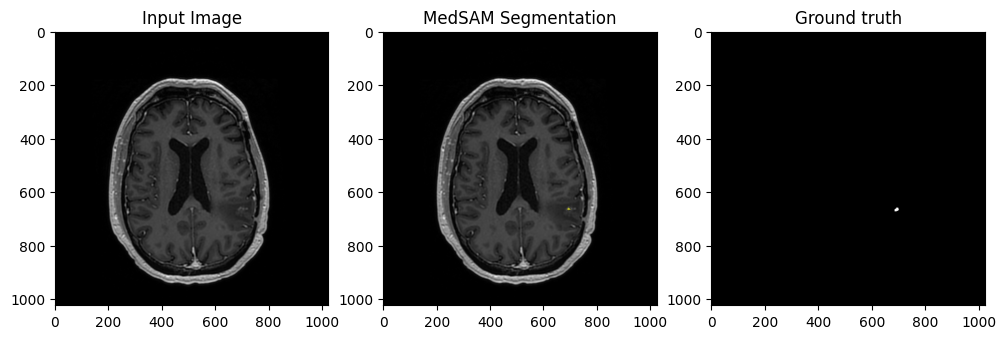

Dice score: 0.7084870934486389


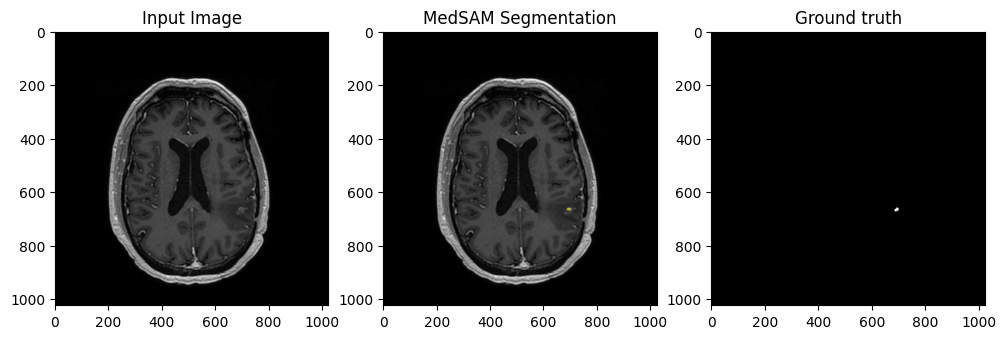

Dice score: 0.7761194109916687


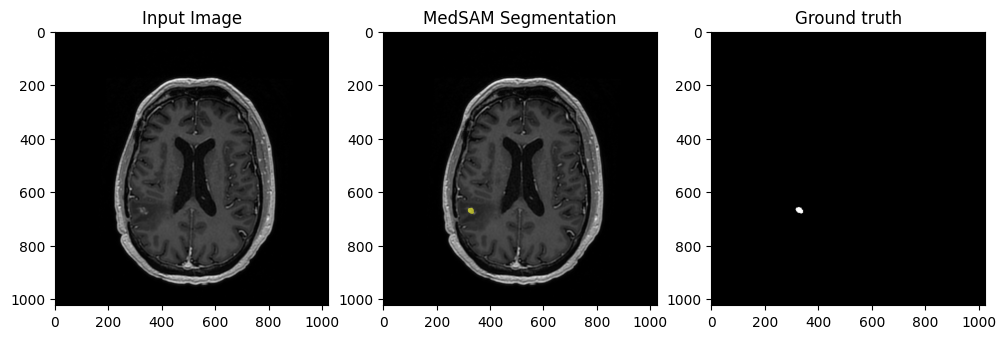

Dice score: 0.8187500238418579


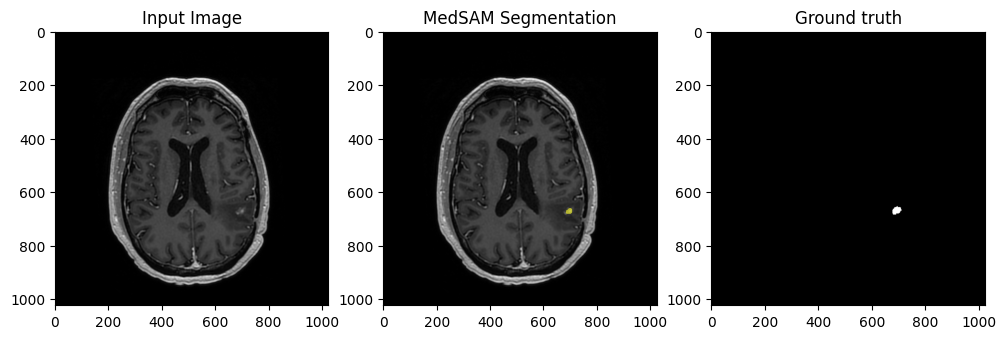

Dice score: 0.7218167185783386


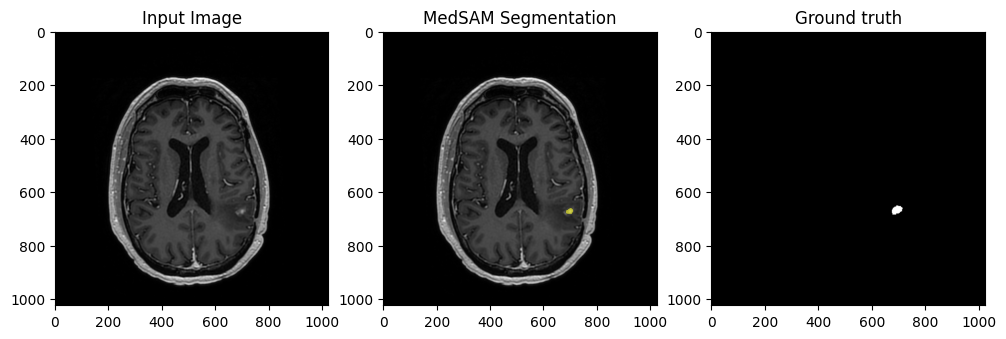

Dice score: 0.6113360524177551


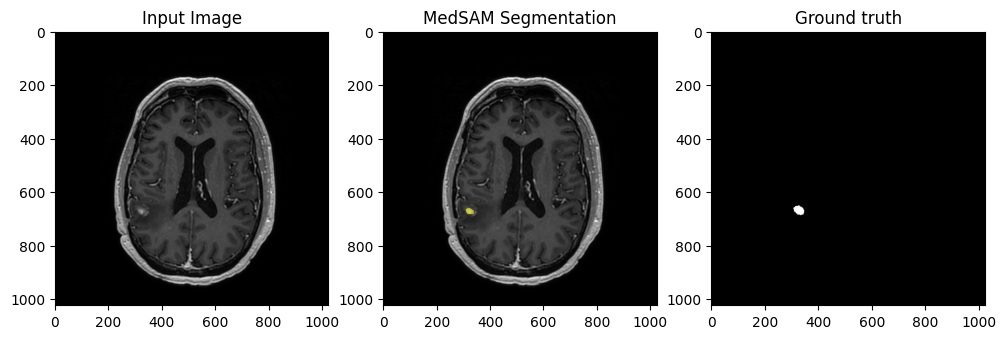

Dice score: 0.6682634949684143


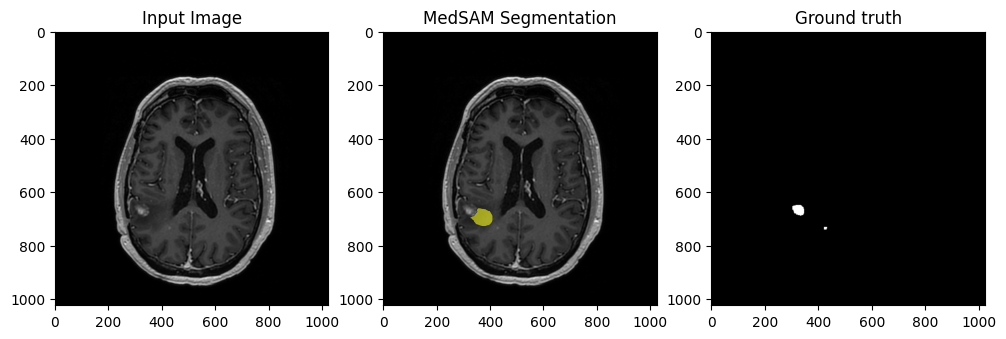

Dice score: 0.0018395879305899143


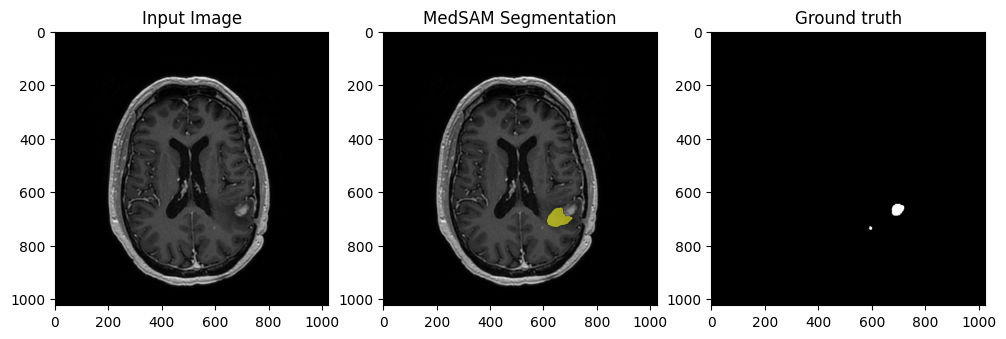

Dice score: 0.0003198976337444037


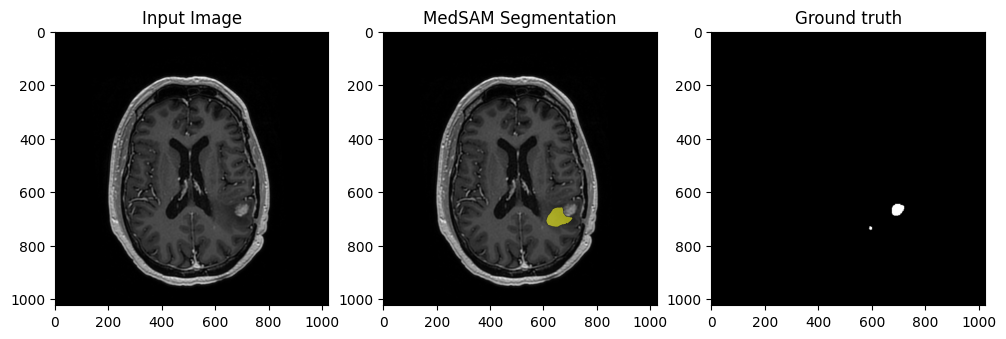

Dice score: 1.5994882501813024e-11


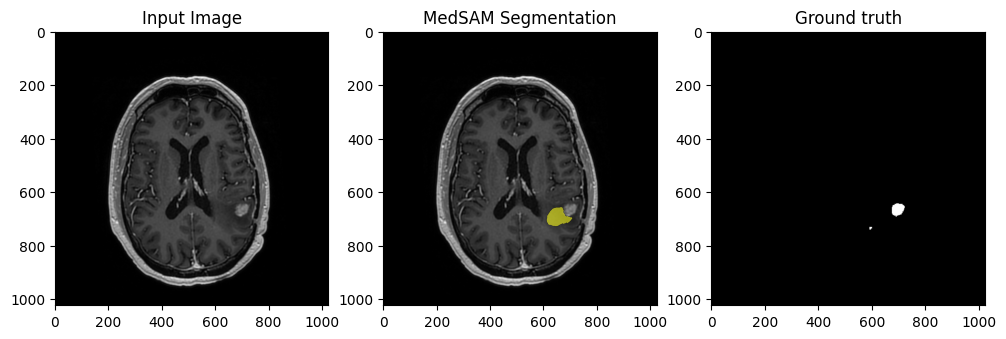

Dice score: 0.005314991343766451


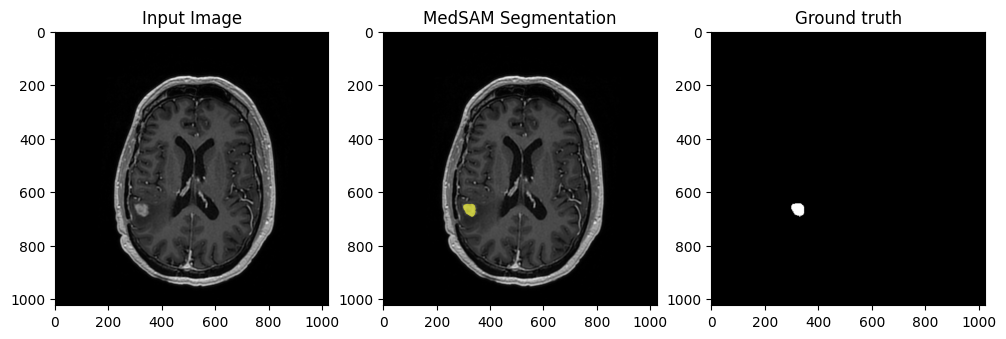

Dice score: 0.9459459185600281


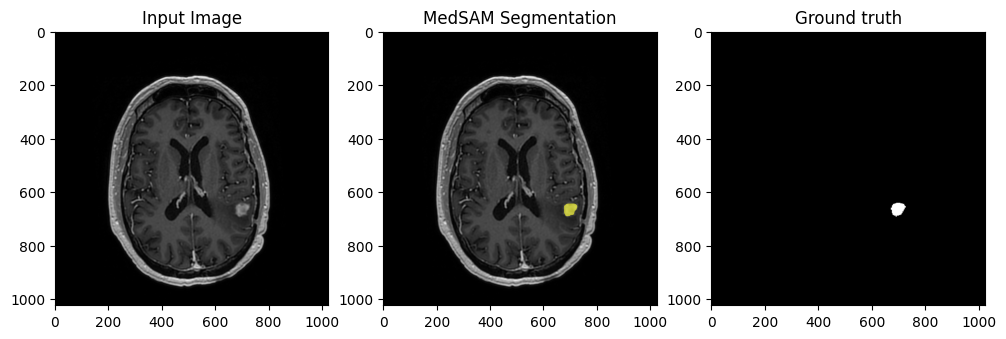

Dice score: 0.948685884475708


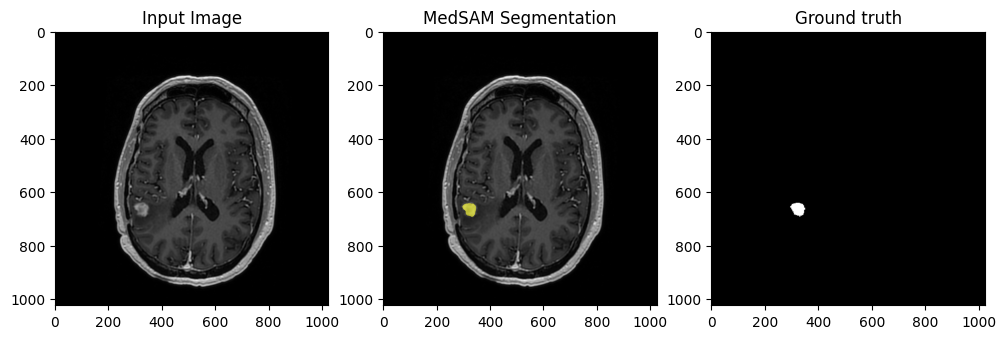

Dice score: 0.9428997039794922


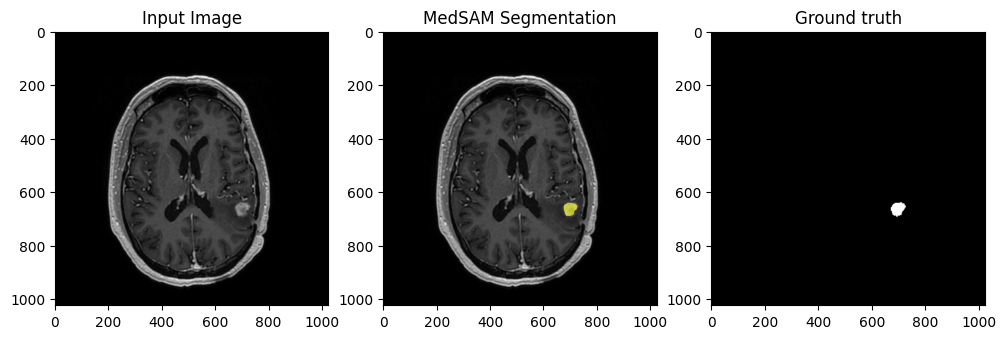

Dice score: 0.9465060234069824


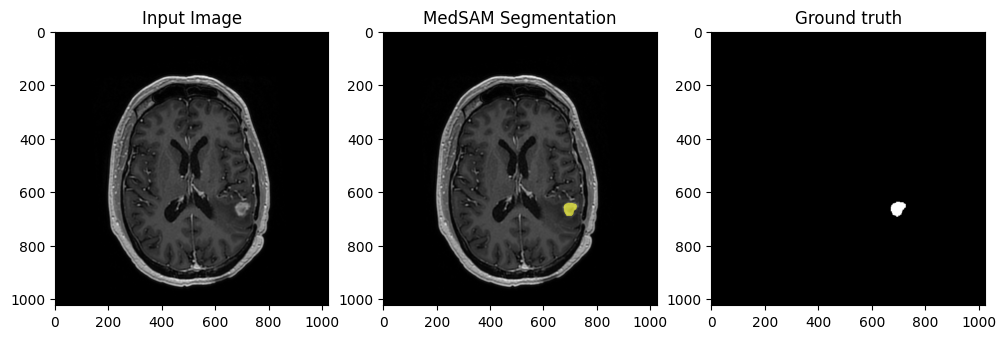

Dice score: 0.9227498173713684


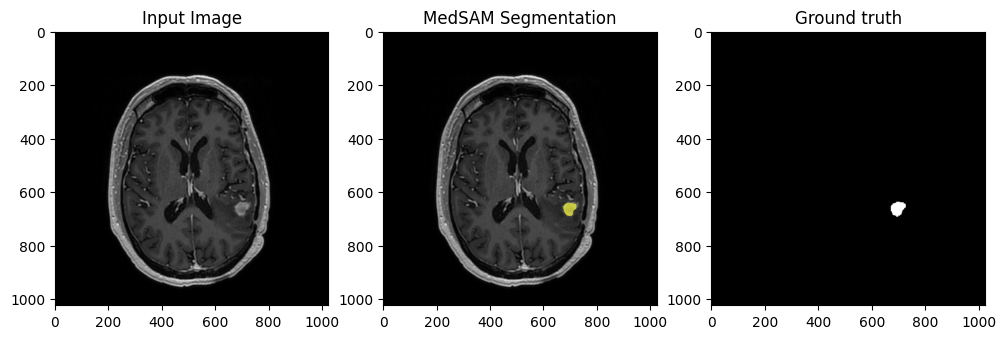

Dice score: 0.9227457642555237


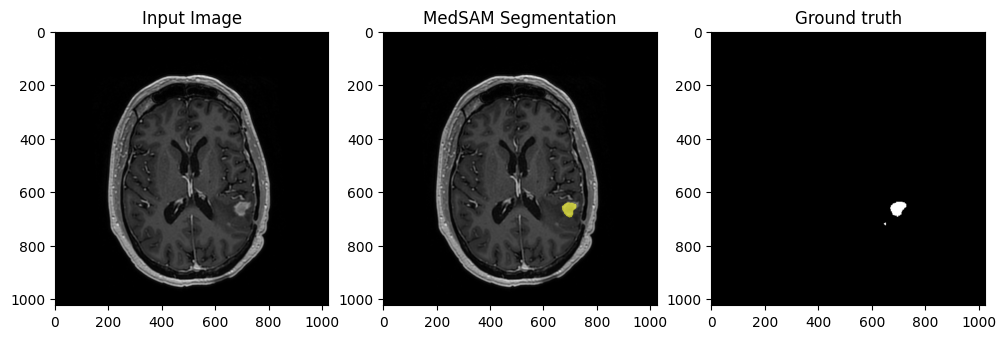

Dice score: 0.8828867673873901



KeyboardInterrupt



<Figure size 1200x500 with 3 Axes>

Dice score: 0.8257607221603394


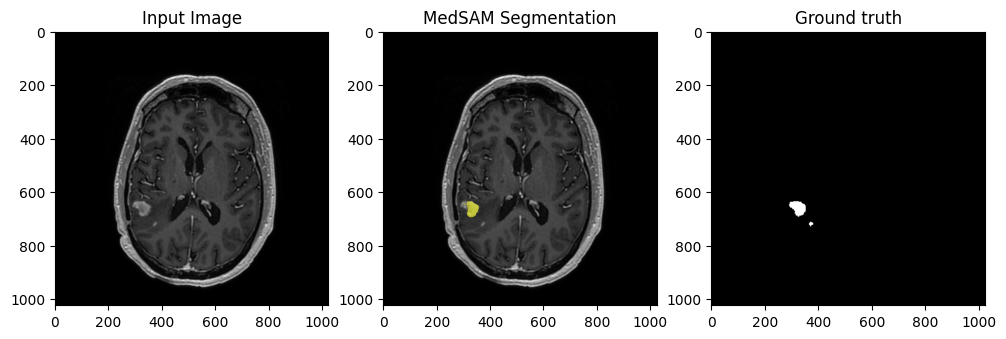

Dice score: 0.7864336967468262


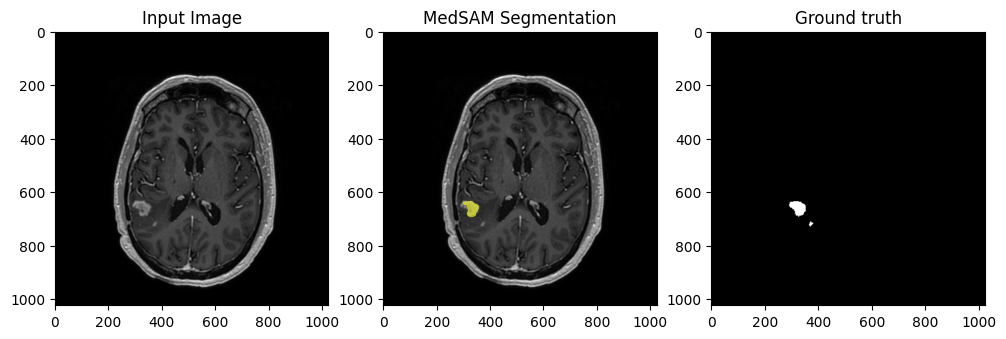

Dice score: 0.8100668787956238


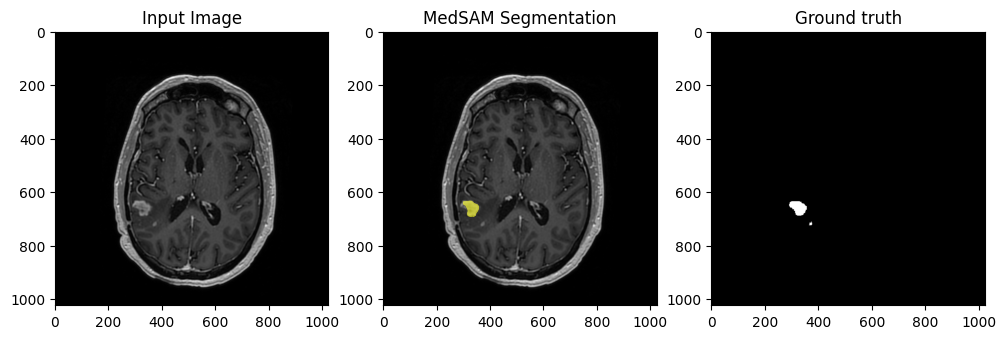

Dice score: 0.8452655673027039


Exception ignored in: <Finalize object, dead>
Traceback (most recent call last):
  File "/home/dgaviria/anaconda3/envs/gpu/lib/python3.11/multiprocessing/util.py", line 224, in __call__
    res = self._callback(*self._args, **self._kwargs)
          ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/dgaviria/anaconda3/envs/gpu/lib/python3.11/multiprocessing/util.py", line 466, in close_fds
    os.close(fd)
KeyboardInterrupt: 


KeyboardInterrupt: 

In [ ]:
for images, masks in val_dataloader:
    images = images.to(device)        # [1,1,H,W]
    masks  = masks.to(device)

    # repeat channel for SAM
    images_sam = images
    if images.shape[1] == 1:
        images_sam = images.repeat(1, 3, 1, 1)  # now [1,3,H,W]

    box_np = [get_bounding_box_from_mask(masks)]

    with torch.no_grad():
        # feed 3‑channel tensor to image_encoder
        image_embedding = medsam_model.image_encoder(images_sam)
        medsam_seg       = medsam_inference(
            medsam_model,
            image_embedding,
            box_np,
            H=images.shape[-2],
            W=images.shape[-1],
        )

    # your UNet prediction as before
    outputs = model(images) if not isinstance(model(images), dict) else model(images)["out"]
    pred    = torch.sigmoid(outputs) > 0.01

    # plotting (unchanged)
    fig, ax = plt.subplots(1, 3, figsize=(12, 5))
    ax[0].imshow(images[0,0].cpu().numpy(), cmap='gray')
    ax[0].set_title("Input Image")

    ax[1].imshow(images[0,0].cpu().numpy(), cmap='gray')
    show_mask(medsam_seg, ax[1])
    ax[1].set_title("MedSAM Segmentation")

    ax[2].imshow(masks[0,0].cpu().numpy(), cmap='gray')
    ax[2].set_title("Ground truth")
    plt.show()

    outputs = torch.from_numpy(medsam_seg).float().unsqueeze(0).unsqueeze(0).to(device)
    print('Dice score:', dice_score(outputs, masks))





<div class="alert alert-block alert-info">
<b>Conclude.</b> Based on the computation time of fine-tuning models like FCN, the performance and ease of use, which model would you recommend?
</div>

In this notebook, we explored multiple segmentation strategies for medical imaging, including fully supervised models like FCN and prompt-based models like MedSAM. While FCN offers full automation and decent performance with proper training, it requires significant computational resources and annotated data for fine-tuning. In contrast, MedSAM provides an efficient and flexible alternative: it enables high-quality segmentation with minimal supervision by leveraging prompt-based interaction (e.g., bounding boxes). For practical applications—especially when manual annotations are limited or real-time feedback is needed—MedSAM is a compelling choice. However, when a large, labeled dataset is available and full automation is essential, training or fine-tuning a model like FCN or UNet remains a solid, high-performance option. Choosing the best model ultimately depends on your data availability, time constraints, and desired level of control.

In [ ]:
import torch
import torchvision

print(f"PyTorch version: {torch.__version__}")
print(f"Torchvision version: {torchvision.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")

PyTorch version: 2.7.1+cu126
Torchvision version: 0.22.1+cu126
CUDA available: True


The error `RuntimeError: operator torchvision::nms does not exist` typically arises from a version mismatch between PyTorch and torchvision, especially when CUDA is involved.

A potential fix is to reinstall both PyTorch and torchvision, ensuring that the versions are compatible and built with CUDA support. I will provide a command to do this. Note that this might take some time to complete.

In [ ]:
!pip uninstall -y torch torchvision torchaudio
!pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu118

Found existing installation: torch 2.6.0
Uninstalling torch-2.6.0:
  Successfully uninstalled torch-2.6.0
Found existing installation: torchvision 0.22.1+cu118
Uninstalling torchvision-0.22.1+cu118:
  Successfully uninstalled torchvision-0.22.1+cu118
Found existing installation: torchaudio 2.7.1+cu118
Uninstalling torchaudio-2.7.1+cu118:
  Successfully uninstalled torchaudio-2.7.1+cu118
Looking in indexes: https://download.pytorch.org/whl/cu118
  Using cached https://download.pytorch.org/whl/cu118/torch-2.7.1%2Bcu118-cp311-cp311-manylinux_2_28_x86_64.whl.metadata (28 kB)
  Using cached https://download.pytorch.org/whl/cu118/torchvision-0.22.1%2Bcu118-cp311-cp311-manylinux_2_28_x86_64.whl.metadata (6.1 kB)
  Using cached https://download.pytorch.org/whl/cu118/torchaudio-2.7.1%2Bcu118-cp311-cp311-manylinux_2_28_x86_64.whl.metadata (6.6 kB)
  Using cached https://download.pytorch.org/whl/sympy-1.13.3-py3-none-any.whl.metadata (12 kB)
  Using cached https://download.pytorch.org/whl/triton-

After the reinstallation, please run the cell with the imports again to see if the issue is resolved.